## -----------------------------------------------------------------------------
## INITIALIZATION
## -----------------------------------------------------------------------------
useful lines:

with_rx.printSchema()

train_df.select("ENROLID").distinct().count()

df_2018.groupBy("cost_stratum_2018").count().orderBy("cost_stratum_2018").show()


In [1]:
import sys
print(f"Python version: {sys.version}")
import json
import logging
import csv
import gzip
import re
import pandas as pd
import numpy as np
from functools import reduce
from pyspark.sql.types import StringType,DecimalType,DoubleType,IntegerType
from pyspark.ml import Pipeline
from pyspark.ml.feature import StringIndexer, OneHotEncoder
from pyspark.ml.feature import VectorAssembler, Bucketizer
import matplotlib.pyplot as plt
import pyspark.sql.functions as F
import pyspark.sql.types as T
from pyspark.sql import SparkSession,Row
from pyspark import SparkConf
import plotly.express as px
import plotly.graph_objects as go
from pyspark.sql.window import Window
from pyspark.sql.functions import row_number, col
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

# -----------------------------------------------------------------------------
# INITIALIZE LOGGING
# -----------------------------------------------------------------------------
f = '%(asctime)-15s %(levelname)-8s %(message)s'
logger = logging.getLogger(__name__)
logger.setLevel("DEBUG")
logging.basicConfig(format=f)


from IPython.core.magic import register_cell_magic

# -----------------------------------------------------------------------------
# start_spark
# -----------------------------------------------------------------------------
def start_spark(
    driver_memory="100g",
    storage_fraction=0.5,
    num_nodes=10,
):
    """Initialize spark

    Arguments:
        driver_memory: Maximum heap size for the Spark driver Java
            virtual machine.
        storage_fraction: Controls what portion of Spark's unified
            memory is reserved for storage (i.e., caching/persisting data
            and broadcast variables), as a fraction of the total
            execution + storage memory pool.
            If you cache/persist a lot of data, and you're evicting
            data too early, you might increase this value (e.g. 0.6 or 0.7).
            Conversely, if your job is shuffle-heavy and fails due to
            memory pressure, you might decrease it (e.g. 0.3).
        num_nodes: How many concurrent threads to use while running
            in "local mode" (i.e. in a single machine instead of a cluster).
            Use '*' to use all cores, or an integer > 0 for a specific
            number of threads.
    """

    conf = SparkConf().setAppName("My_Application")
    conf.set("spark.driver.memory", driver_memory)
    conf.set("spark.memory.storageFraction", str(storage_fraction))
    conf.setMaster(f"local[{num_nodes}]")

    spark = SparkSession.builder.config(conf=conf).getOrCreate()
    spark.sparkContext.setLogLevel('WARN')

    return spark


Python version: 3.11.0 (main, Jun 13 2025, 14:48:45) [Clang 16.0.0 (clang-1600.0.26.6)]


In [2]:

spark = start_spark(num_nodes=10)
#spark.stop()

  
@register_cell_magic
def spark_sql(line, cell):
    result = spark.sql(cell)
    result.show(n=1000)
  

# -- READ ENROLLMENT AND DATA TABLES
enrollment_file = f"/Users/Charles/DATA/ckd/ckd_enrollment"
logger.info(f">>> Reading enrollment file: {enrollment_file}")
df_enrollment = spark.read.format("parquet").load(enrollment_file)
df_enrollment.createOrReplaceTempView('enrollment')
logger.info(f">>> ENROLLMENT has {df_enrollment.count():,} rows")
logger.info(f">>> ENROLLMENT has {df_enrollment.select('ENROLID').distinct().count():,} unique enrollees")

claims_file = f"/Users/Charles/DATA/ckd/ckd_claims"
logger.info(f">>> Reading claims file: {claims_file}")
df_claims = spark.read.format("parquet").load(claims_file)
df_claims.createOrReplaceTempView('claims')
logger.info(f">>> CLAIMS has {df_claims.count():,} rows")
logger.info(f">>> CLAIMS has {df_claims.select('ENROLID').distinct().count():,} unique enrollees")

# -- NOTE: with the "createOrReplaceTempView" we define a view of these
# -- tables, so we can use them in SQL queries.

Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
25/08/25 11:40:40 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable
2025-08-25 11:40:42,116 INFO     >>> Reading enrollment file: /Users/Charles/DATA/ckd/ckd_enrollment
25/08/25 11:40:43 WARN SparkStringUtils: Truncated the string representation of a plan since it was too large. This behavior can be adjusted by setting 'spark.sql.debug.maxToStringFields'.
2025-08-25 11:40:43,711 INFO     >>> ENROLLMENT has 2,586,930 rows
2025-08-25 11:40:45,398 INFO     >>> ENROLLMENT has 862,310 unique enrollees    
2025-08-25 11:40:45,399 INFO     >>> Reading claims file: /Users/Charles/DATA/ckd/ckd_claims
2025-08-25 11:40:46,387 INFO     >>> CLAIMS has 253,070,875 rows                
2025-08-25 11:40:53,761 INFO     >

# Load Data

In [27]:
############### merge 2017/18 with 2018/19 cohorts and add suffix to repeated ENROLID
from pyspark.sql.functions import concat_ws, col
#df_2018 =spark.read.format("parquet").load( "0813_adherence_features_2017.parquet")
df_2018 =spark.read.format("parquet").load( "0813_cost_features_2017.parquet")
#df_2018 =spark.read.format("parquet").load( "df_0714_2017_18_with_THERCLS.parquet")
df_og = df_2018.toPandas()
df_og["INDSTRY"] = df_og["INDSTRY"].fillna("-1")
#df_og.drop(columns = [ 'first_ckd_date', 'ckd_visit_count', 'quarters_with_labs','nephrology_visit_count', 'days_to_nephrology','first_nephrology_date',],inplace=True)



In [28]:
highcost_cutoff = 4
stratifier_cutoff = 3

import importlib
import model_pipeline
importlib.reload(model_pipeline)

# Correctly import your custom modules
import evaluate_model_by_cost_stratum
import evaluate_model_by_risk_bin

# Then reload them
importlib.reload(evaluate_model_by_risk_bin)
importlib.reload(evaluate_model_by_cost_stratum)

<module 'evaluate_model_by_cost_stratum' from '/Users/cat2510/my_projects/evaluate_model_by_cost_stratum.py'>

# Feature groups, define high cost and train-test-split

In [29]:
BIN_FLAG_COLUMNS = model_pipeline.get_bin_flag_columns(df_og) +['lab_monitoring_adherent','nephrology_consult_adherent','early_nephrology_referral']
STAGE_COLUMNS = ['2017Q1', '2017Q2', '2017Q3', '2017Q4',"stage_2017",'2017Q1_max_ckd_stage','2017Q2_max_ckd_stage', '2017Q3_max_ckd_stage','2017Q4_max_ckd_stage', ]
CAT_COLUMNS = df_og.select_dtypes(include=["object","category"]).columns.tolist()
TRUE_NUM_COLUMNS = model_pipeline.get_true_num_columns(df_og,CAT_COLUMNS)+[ 'util_2017', 'total_increasing_quarters_2017'
, 'total_lab_tests', ]
print(CAT_COLUMNS)

leftover_cols = [
    c for c in df_og.columns 
    if c not in CAT_COLUMNS and c not in TRUE_NUM_COLUMNS and c not in STAGE_COLUMNS and c not in BIN_FLAG_COLUMNS 
]

print(f"Number of leftover columns: {len(leftover_cols)}")
print(leftover_cols, df_og.shape)  # preview first 50

['ENROLID', 'AGEGRP', 'SEX', 'REGION', 'INDSTRY']
Number of leftover columns: 0
[] (33590, 61)


In [30]:
df_og["high_cost_2018"] = (df_og["cost_stratum_2018"] >= highcost_cutoff).astype(int)
feature_cols = [c for c in df_og.columns
              if c not in  ("ENROLID","cost_stratum_2018", "high_cost_2018")]    # keep only predictors
numeric_cols = df_og[feature_cols + ["high_cost_2018"]].select_dtypes(include=["number"]).columns
corrs = df_og[numeric_cols].corr()["high_cost_2018"].abs().sort_values(ascending=False)
# Columns to drop
high_corr_cols = corrs[corrs > 0.5].index.tolist()
# Remove the target column itself, if present
high_corr_cols = [col for col in high_corr_cols if col != "high_cost_2018"]
# Final filtered feature set
feature_cols = [col for col in feature_cols if col not in high_corr_cols]
print("High corr features to drop: ",high_corr_cols)
# 2) split
train_ids, test_ids,train_pd,test_pd = model_pipeline.train_test_split_enrol(df_og,test_size=0.3,verbose=False)

print(train_pd.shape,test_pd.shape)
#baseline_results = evaluate_model_by_cost_stratum.analyze_predictions_by_cost_strata(baselinemodel,test_pd[feature_cols],
#test_pd["cost_stratum_2018"], highcost_cutoff=highcost_cutoff,optimal_threshold=True)


High corr features to drop:  []
(23513, 62) (10077, 62)


# Stratification

In [31]:
df_pd = df_og.copy()

In [32]:
#stratifier_train_pd = df_pd[df_pd["stage_2017"] > 3]
stratifier_train_pd = df_pd[df_pd["stage_2017"] <= 3]
print("Stratifier trained on subgroup of size ",len(stratifier_train_pd))
stratification_cols = [c for c in feature_cols
              if c not in  STAGE_COLUMNS]    # keep only predictors


Stratifier trained on subgroup of size  28591


In [ ]:
stratifier_train_pd["y_high"] = (df_og["cost_stratum_2018"] >= stratifier_cutoff).astype(int)

# 3) Train/Test split (optional; here we train on all Stage 3)
stratifier_Xtrain = stratifier_train_pd[stratification_cols]
stratifier_ytrain = stratifier_train_pd["y_high"]


stratifier = model_pipeline.get_logistic_pipeline(df=stratifier_Xtrain,categorical_cols=CAT_COLUMNS, numeric_cols=TRUE_NUM_COLUMNS,max_iter = 500,scale_post_preprocess=True,calibrate=False)
stratifier.fit(stratifier_Xtrain, stratifier_ytrain)

# ─── 5) Apply to the full cohort ─────────────────────────────────────────────
X_full = df_pd[stratification_cols]
proba_high = stratifier.predict_proba(X_full)[:,1]
df_pd["proba_high_2018"] = proba_high
print("Inference on full cohort of size: ", len(proba_high))

→ Building preprocessor:
   • OneHotEncoder on: ['AGEGRP', 'SEX', 'REGION', 'INDSTRY']
   • StandardScaler on: ['cost_stratum_2017', '2017Q1_ckd_cost', '2017Q1_ckd_claims', '2017Q1_direct_ckd_cost', '2017Q1_procedure_ckd_cost', '2017Q1_comorbidity_ckd_cost', '2017Q2_ckd_cost', '2017Q2_ckd_claims', '2017Q2_direct_ckd_cost', '2017Q2_procedure_ckd_cost', '2017Q2_comorbidity_ckd_cost', '2017Q3_ckd_cost', '2017Q3_ckd_claims', '2017Q3_direct_ckd_cost', '2017Q3_procedure_ckd_cost', '2017Q3_comorbidity_ckd_cost', '2017Q4_ckd_cost', '2017Q4_ckd_claims', '2017Q4_direct_ckd_cost', '2017Q4_procedure_ckd_cost', '2017Q4_comorbidity_ckd_cost', 'total_ckd_cost_2017', 'ckd_cost_trend_2017', 'ckd_cost_volatility_2017', 'util_2017']
Inference on full cohort of size:  33590


/var/folders/mb/36y0j9bs5117v9zxrdzlbxkc0000gv/T/ipykernel_34593/1562461667.py:2: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



In [34]:
import balancing_functions.optimal_match_control
importlib.reload(balancing_functions.optimal_match_control)
from balancing_functions.optimal_match_control import *
# Initialize your enhanced resampler
sampler_initial = EnhancedRiskBinnedCaseControlResampler(
    bin_edges=np.linspace(0, 1, 11),
    uid_col="ENROLID",
    binary_group="true_class",
    proba_col="proba_high_2018",
    random_state=42
)

# Get the optimized strategies for high-cost detection
strategies = get_high_cost_detection_config()

# Assign risk bins to your data
df_binned = sampler_initial.assign_bins(df_pd)

# 2) Create your binary “true_class” from the stage_group
df_binned["true_class"] = (df_binned["stage_2017"] > 3).astype(int)
#   – now true_class=1 are stage>3, and 0 are stage≤3
df_binned.drop(["cost_stratum_2018",'high_cost_2018'],axis=1,inplace=True)

In [35]:
train_df_matching = df_binned[df_binned["ENROLID"].isin(train_ids)].reset_index(drop=True)
test_df  = df_binned[df_binned["ENROLID"].isin(test_ids)].reset_index(drop=True)
print("Train size:", len(train_df_matching), "Test size:", len(test_df))
bins = list(train_df_matching["risk_bin"].cat.categories)   # already ordered
fig = px.histogram(
    train_df_matching,
    x="risk_bin",
    color="true_class",
    labels={
        "risk_bin": f"Predicted P(cost_stratum_2018 >= {stratifier_cutoff})",
        "true_class": "Stage ≤3 vs >3"
    },
    title="Train Set: High-Cost Risk by 2017 CKD Stage Group (Logistic Regression)",
    barmode="group",
    height=500, width=800
)
fig.update_xaxes(
    categoryorder="array",
    categoryarray=bins,      # <- enforce ascending order
    tickangle=-45
)
fig.show()

Train size: 23513 Test size: 10077


# Matching

In [90]:
importlib.reload(balancing_functions.optimal_match_control)
from balancing_functions.optimal_match_control import *


# Create your resampler with OR-Tools
sampler = EnhancedRiskBinnedCaseControlResampler(
    matching_method="ortools",  # Use OR-Tools for optimization
    random_state=42,
    proba_col="proba_high_2018",  # Your probability column
    binary_group="true_class",       # Your binary target column
    uid_col="ENROLID"            # Your ID column
)

# Get bin strategies optimized for OR-Tools
strategies = get_high_cost_detection_config(primary_matching_method="ortools")

# Calculate the size of the smallest bin before matching
bin_counts = train_df_matching["risk_bin"].value_counts()
smallest_bin_size = bin_counts.min()
print(f"Smallest bin size before matching: {smallest_bin_size}")
print(f"Bin sizes before matching: {bin_counts.to_dict()}")

# Apply matching with equalization to the smallest bin size
matched_train_df, removed_ids = sampler.apply_sampler_by_bin(
    train_df_matching,
    bin_specific_strategies=strategies,
    target_bin_size=smallest_bin_size,  # Target the smallest bin size
    verbose=True
)



Smallest bin size before matching: 383
Bin sizes before matching: {'0.00-0.10': 8750, '0.10-0.20': 5213, '0.20-0.30': 3074, '0.30-0.40': 2037, '0.40-0.50': 1485, '0.50-0.60': 982, '0.60-0.70': 690, '0.70-0.80': 493, '0.90-1.00': 406, '0.80-0.90': 383}
Target bin size: 383
→ do_not_impute: ['ENROLID', 'AGEGRP', 'SEX', 'REGION', 'INDSTRY', 'risk_bin', 'ENROLID', 'true_class', 'proba_high_2018']

--- Processing bin 0.00-0.10 (n=8750) ---
>>> Distance computation will use:
    Categorical features: []
    Numeric   features: ['2017Q1', '2017Q2', '2017Q3', '2017Q4', 'stage_2017', 'cost_stratum_2017', 'util_2017', '2017Q1_ckd_cost', '2017Q1_ckd_claims', '2017Q1_max_ckd_stage', '2017Q1_direct_ckd_cost', '2017Q1_procedure_ckd_cost', '2017Q1_comorbidity_ckd_cost', '2017Q2_ckd_cost', '2017Q2_ckd_claims', '2017Q2_max_ckd_stage', '2017Q2_direct_ckd_cost', '2017Q2_procedure_ckd_cost', '2017Q2_comorbidity_ckd_cost', '2017Q3_ckd_cost', '2017Q3_ckd_claims', '2017Q3_max_ckd_stage', '2017Q3_direct_ckd_c

/Users/cat2510/my_projects/balancing_functions/optimal_match_control.py:353: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.



Created 2967396 variables out of 3004980 possible
Starting optimization...
Optimization completed in 305.36 seconds
Optimization successful: 660 cases, 1320 controls
Objective value: 8262.293
Bin 0.10-0.20: 5213 → 1980 (cases: 660 → 660, controls: 4553 → 1320)

--- Processing bin 0.20-0.30 (n=3074) ---
>>> Distance computation will use:
    Categorical features: []
    Numeric   features: ['2017Q1', '2017Q2', '2017Q3', '2017Q4', 'stage_2017', 'cost_stratum_2017', 'util_2017', '2017Q1_ckd_cost', '2017Q1_ckd_claims', '2017Q1_max_ckd_stage', '2017Q1_direct_ckd_cost', '2017Q1_procedure_ckd_cost', '2017Q1_comorbidity_ckd_cost', '2017Q2_ckd_cost', '2017Q2_ckd_claims', '2017Q2_max_ckd_stage', '2017Q2_direct_ckd_cost', '2017Q2_procedure_ckd_cost', '2017Q2_comorbidity_ckd_cost', '2017Q3_ckd_cost', '2017Q3_ckd_claims', '2017Q3_max_ckd_stage', '2017Q3_direct_ckd_cost', '2017Q3_procedure_ckd_cost', '2017Q3_comorbidity_ckd_cost', '2017Q4_ckd_cost', '2017Q4_ckd_claims', '2017Q4_max_ckd_stage', '2017

In [20]:
# Verify the results
print("\nAfter matching with equalization:")
print(f"Total samples: {len(matched_train_df)}")
print(f"Cases: {(matched_train_df['true_class'] == 1).sum()}")
print(f"Controls: {(matched_train_df['true_class'] == 0).sum()}")
print(f"Bin sizes after matching: {matched_train_df['risk_bin'].value_counts().to_dict()}")


# Extract matched IDs
matched_ids_df = (
    matched_train_df[["ENROLID"]]
    .drop_duplicates()
    .reset_index(drop=True)
)


After matching with equalization:
Total samples: 7667
Cases: 2570
Controls: 5097
Bin sizes after matching: {'0.10-0.20': 2596, '0.20-0.30': 2060, '0.30-0.40': 496, '0.40-0.50': 496, '0.50-0.60': 372, '0.60-0.70': 372, '0.90-1.00': 372, '0.70-0.80': 328, '0.00-0.10': 323, '0.80-0.90': 252}


In [91]:
bins = [f"{x:.1f}-{x+0.1:.1f}" for x in np.arange(0.0, 1.0, 0.1)]

fig = px.histogram(
    matched_train_df,
    x="risk_bin",
    color="true_class",
    category_orders={"risk_bin": bins},   # good to keep
    labels={
        "risk_bin": f"Predicted P(cost_stratum_2018 >= {stratifier_cutoff})",
        "true_class": "Stage ≤3 vs >3"
    },
    title="Matched Cohort: High-Cost Risk by 2017 CKD Stage Group",
    barmode="group",
    height=500, width=800
)

# *** pin the x-axis order ***
fig.update_xaxes(categoryorder="array", categoryarray=bins)

fig.update_layout(xaxis_tickangle=-45)
fig.show()

In [92]:
# 1) Collapse to one row per ENROLID
matched_ids_df = (
    matched_train_df[["ENROLID"]]
      .drop_duplicates()
      .reset_index(drop=True)
)

# 2) Pull in the target from your original train set
matched_with_target = matched_ids_df.merge(
    train_pd[["ENROLID", "high_cost_2018"]],
    on="ENROLID",
    how="inner"
)
print(matched_with_target.shape)
print(CAT_COLUMNS)


(5657, 2)
['ENROLID', 'AGEGRP', 'SEX', 'REGION', 'INDSTRY']


In [79]:
# In your main file, here's how to achieve equal bin sizes with balanced cases/controls

# 1. First, identify the variables to include in matching
# These are the ones you specifically want to match on
matching_variables = [
    #'total_lab_tests', 'lab_monitoring_adherent', 'nephrology_consult_adherent', 'early_nephrology_referral',
    # Binary features (disease indicators)
    'has_Hypertension', 'has_Type_2_Diabetes', 'has_Anemia', 'has_Hyperlipidemia', 
    'has_Acute_Kidney_Failure', 'has_Hyperparathyroidism', 'has_Kidney_Transplant',
    'has_Vitamin_D_Deficiency', 'has_Long-term_Drug_Therapy', 'has_Hypothyroidism', 
    'has_Sleep_Apnea',
    
    # Treatment class indicators
    'THRCLS_53', 'THRCLS_51', 'THRCLS_52', 'THRCLS_69', 'THRCLS_46', 'THRCLS_47', 
    'THRCLS_172', 'THRCLS_174', 'THRCLS_181', 'THRCLS_60',
    
    # Demographics (look for these in your dataset)
    'AGEGRP', 'SEX', 'REGION', 'INDSTRY'
]

# 2. Define all variables to exclude from matching (everything NOT in matching_variables)
# You'll need to adjust this based on your actual column names
exclude_from_matching = [col for col in train_df_matching.columns 
                        if col not in matching_variables
                        and col not in ['ENROLID', 'risk_bin']]

# 3. Create the resampler with ortools for best performance
sampler = EnhancedRiskBinnedCaseControlResampler(
    matching_method="ortools",
    random_state=42,
    proba_col="proba_high_2018",
    binary_group="true_class",
    uid_col="ENROLID"
)

# 4. Find the smallest bin size for target
bin_counts = train_df_matching["risk_bin"].value_counts()
smallest_bin_size = bin_counts.min()
print(f"Smallest bin size before matching: {smallest_bin_size}")
print(f"Bin sizes before matching: {bin_counts.to_dict()}")

# 5. Create a simple custom function that ensures each bin has equal cases/controls
def equalize_all_bins(df, target_bin_size):
    """
    Process all bins to have equal numbers of cases and controls,
    with total bin size equal to target_bin_size
    """
    result_bins = []
    
    # Process each bin
    for bin_name, bin_df in df.groupby("risk_bin"):
        print(f"\nProcessing bin {bin_name} (n={len(bin_df)})")
        
        # Get cases and controls
        cases = bin_df[bin_df["true_class"] == 1]
        controls = bin_df[bin_df["true_class"] == 0]
        
        # Calculate how many to keep (half the target size for each)
        half_target = target_bin_size // 2
        
        # Sample cases and controls
        if len(cases) > half_target:
            # If we have more than needed, use matching to find best subset
            if len(cases) > 0 and len(controls) > 0:
                # Use matching to find the best subset
                matched_bin = sampler.match_case_control(
                    bin_df,
                    target_cases=half_target,
                    target_controls=half_target,
                    exclude_cols=exclude_from_matching,
                    verbose=True
                )
                
                # Verify we got the right counts
                actual_cases = (matched_bin["true_class"] == 1).sum()
                actual_controls = (matched_bin["true_class"] == 0).sum()
                print(f"After matching: {actual_cases} cases, {actual_controls} controls")
                
                # If matching didn't give us the exact counts we want, force them
                if actual_cases != half_target or actual_controls != half_target:
                    print(f"Adjusting to exact counts ({half_target} each)...")
                    
                    # Get matched cases and controls
                    matched_cases = matched_bin[matched_bin["true_class"] == 1]
                    matched_controls = matched_bin[matched_bin["true_class"] == 0]
                    
                    if len(matched_cases) > half_target:
                        print("Sampling down cases")
                        matched_cases = matched_cases.sample(n=half_target, random_state=42)
                    if len(matched_controls) > half_target:
                        print("Sampling down controls")
                        matched_controls = matched_controls.sample(n=half_target, random_state=42)
                    
                    if len(matched_cases) < half_target:
                        print("Sample up cases from original (this is suboptimal but ensures counts)")
                        remaining_needed = half_target - len(matched_cases)
                        unmatched_cases = cases[~cases[sampler.uid_col].isin(matched_cases[sampler.uid_col])]
                        if len(unmatched_cases) >= remaining_needed:
                            extra_cases = unmatched_cases.sample(n=remaining_needed, random_state=42)
                            matched_cases = pd.concat([matched_cases, extra_cases])
                    
                    if len(matched_controls) < half_target:
                        print("Sample up controls from original (this is suboptimal but ensures counts)")
                        remaining_needed = half_target - len(matched_controls)
                        unmatched_controls = controls[~controls[sampler.uid_col].isin(matched_controls[sampler.uid_col])]
                        if len(unmatched_controls) >= remaining_needed:
                            extra_controls = unmatched_controls.sample(n=remaining_needed, random_state=42)
                            matched_controls = pd.concat([matched_controls, extra_controls])
                    
                    matched_bin = pd.concat([matched_cases, matched_controls])
                
                result_bins.append(matched_bin.assign(risk_bin=bin_name))
            else:
                print("Not enough of one class, just sample randomly")
                cases_to_keep = min(len(cases), half_target)
                controls_to_keep = min(len(controls), half_target)
                
                sampled_cases = cases.sample(n=cases_to_keep, random_state=42)
                sampled_controls = controls.sample(n=controls_to_keep, random_state=42)
                
                result_bins.append(pd.concat([sampled_cases, sampled_controls]).assign(risk_bin=bin_name))
        else:
            # If we have fewer cases than half_target, keep all cases and match controls
            cases_to_keep = len(cases)
            controls_to_keep = min(len(controls), target_bin_size - cases_to_keep)
            
            if len(controls) > controls_to_keep:
                # Use matching to find the best subset of controls
                matched_controls = sampler.match_case_control(
                    pd.concat([cases, controls]),
                    target_cases=cases_to_keep,
                    target_controls=controls_to_keep,
                    exclude_cols=exclude_from_matching,
                    verbose=True
                )
                
                # Ensure we kept all cases
                if (matched_controls["true_class"] == 1).sum() != cases_to_keep:
                    # Something went wrong, fall back to simple sampling
                    print("Warning: Matching didn't preserve all cases. Using simple sampling.")
                    sampled_controls = controls.sample(n=controls_to_keep, random_state=42)
                    matched_bin = pd.concat([cases, sampled_controls])
                    result_bins.append(matched_bin.assign(risk_bin=bin_name))
                else:
                    result_bins.append(matched_controls.assign(risk_bin=bin_name))
            else:
                # Not enough controls, keep all we have
                result_bins.append(pd.concat([cases, controls]).assign(risk_bin=bin_name))
    
    # Combine all processed bins
    result_df = pd.concat(result_bins, ignore_index=True)
    
    # Print final stats
    print("\nFinal bin sizes:")
    for bin_name, bin_df in result_df.groupby("risk_bin"):
        cases = (bin_df["true_class"] == 1).sum()
        controls = (bin_df["true_class"] == 0).sum()
        print(f"Bin {bin_name}: {len(bin_df)} total ({cases} cases, {controls} controls)")
    
    return result_df

# 6. Apply the function to get balanced bins
matched_train_df = equalize_all_bins(train_df_matching, smallest_bin_size)

# 7. Extract the matched IDs
matched_ids_df = matched_train_df[["ENROLID"]].drop_duplicates().reset_index(drop=True)

Smallest bin size before matching: 383
Bin sizes before matching: {'0.00-0.10': 8750, '0.10-0.20': 5213, '0.20-0.30': 3074, '0.30-0.40': 2037, '0.40-0.50': 1485, '0.50-0.60': 982, '0.60-0.70': 690, '0.70-0.80': 493, '0.90-1.00': 406, '0.80-0.90': 383}

Processing bin 0.00-0.10 (n=8750)
>>> Distance computation will use:
    Categorical features: ['AGEGRP', 'SEX', 'REGION', 'INDSTRY']
    Numeric   features: []
    Binary    features : ['has_Hypertension', 'has_Type_2_Diabetes', 'has_Anemia', 'has_Hyperlipidemia', 'has_Acute_Kidney_Failure', 'has_Hyperparathyroidism', 'has_Kidney_Transplant', 'has_Vitamin_D_Deficiency', 'has_Long-term_Drug_Therapy', 'has_Hypothyroidism', 'has_Sleep_Apnea', 'THRCLS_53', 'THRCLS_51', 'THRCLS_52', 'THRCLS_69', 'THRCLS_46', 'THRCLS_47', 'THRCLS_172', 'THRCLS_174', 'THRCLS_181', 'THRCLS_60']
→ Building preprocessor:
   • OneHotEncoder on: ['AGEGRP', 'SEX', 'REGION', 'INDSTRY']
   • StandardScaler on: []
After preprocessing: 40 features
Binary flag features p

/var/folders/mb/36y0j9bs5117v9zxrdzlbxkc0000gv/T/ipykernel_34593/2222295766.py:51: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.



Created 5242641 variables out of 5242641 possible
Starting optimization...
Optimization completed in 304.83 seconds
Optimization failed: 6, falling back to random sampling
After matching: 191 cases, 191 controls

Processing bin 0.10-0.20 (n=5213)
>>> Distance computation will use:
    Categorical features: ['AGEGRP', 'SEX', 'REGION', 'INDSTRY']
    Numeric   features: []
    Binary    features : ['has_Hypertension', 'has_Type_2_Diabetes', 'has_Anemia', 'has_Hyperlipidemia', 'has_Acute_Kidney_Failure', 'has_Hyperparathyroidism', 'has_Kidney_Transplant', 'has_Vitamin_D_Deficiency', 'has_Long-term_Drug_Therapy', 'has_Hypothyroidism', 'has_Sleep_Apnea', 'THRCLS_53', 'THRCLS_51', 'THRCLS_52', 'THRCLS_69', 'THRCLS_46', 'THRCLS_47', 'THRCLS_172', 'THRCLS_174', 'THRCLS_181', 'THRCLS_60']
→ Building preprocessor:
   • OneHotEncoder on: ['AGEGRP', 'SEX', 'REGION', 'INDSTRY']
   • StandardScaler on: []
After preprocessing: 40 features
Binary flag features preserved: 21
Distance matrix shape: (660

# Model Comparisons

In [68]:
import importlib
import model_pipeline
importlib.reload(model_pipeline)

# Import with correct syntax
import evaluate_model_by_cost_stratum
import evaluate_model_by_risk_bin

# Reload
importlib.reload(evaluate_model_by_cost_stratum)
importlib.reload(evaluate_model_by_risk_bin)
from evaluate_model_by_risk_bin import evaluate_metrics_by_risk_bin, plot_probability_and_calibration


### Baseline Model Comparisons


In [82]:
train_df = df_binned[df_binned["ENROLID"].isin(train_ids)].reset_index(drop=True)
test_df  = df_binned[df_binned["ENROLID"].isin(test_ids)].reset_index(drop=True)
X_train, y_train = train_df_matching[feature_cols], train_pd["high_cost_2018"]
X_test,y_test = test_df[feature_cols], test_pd['high_cost_2018']
X_test.shape

(10077, 59)

In [ ]:
from model_IAI import train_oct_with_feature_names,train_opt_with_feature_names
print(X_train.shape)
iai_model, preprocessor, feature_names = train_oct_with_feature_names(
    X_train, y_train,categorical_cols=CAT_COLUMNS, numeric_cols=TRUE_NUM_COLUMNS
)
iai_model


(23513, 59)
→ Building preprocessor:
   • OneHotEncoder on: ['AGEGRP', 'SEX', 'REGION', 'INDSTRY']
   • StandardScaler on: ['cost_stratum_2017', '2017Q1_ckd_cost', '2017Q1_ckd_claims', '2017Q1_direct_ckd_cost', '2017Q1_procedure_ckd_cost', '2017Q1_comorbidity_ckd_cost', '2017Q2_ckd_cost', '2017Q2_ckd_claims', '2017Q2_direct_ckd_cost', '2017Q2_procedure_ckd_cost', '2017Q2_comorbidity_ckd_cost', '2017Q3_ckd_cost', '2017Q3_ckd_claims', '2017Q3_direct_ckd_cost', '2017Q3_procedure_ckd_cost', '2017Q3_comorbidity_ckd_cost', '2017Q4_ckd_cost', '2017Q4_ckd_claims', '2017Q4_direct_ckd_cost', '2017Q4_procedure_ckd_cost', '2017Q4_comorbidity_ckd_cost', 'total_ckd_cost_2017', 'ckd_cost_trend_2017', 'ckd_cost_volatility_2017', 'util_2017']
=== IAI Optimal Tree with Feature Names ===

Tree Structure:
Fitted OptimalTreeClassifier:
  1) Split: 2017Q4_direct_ckd_cost < 0.2071
    2) Split: 2017Q1_comorbidity_ckd_cost < 0.4031
      3) Predict: 0 (96.75%), [20737,697], 21434 points, error 0.03252
      4

Fitted OptimalTreeClassifier:
  1) Split: 2017Q4_direct_ckd_cost < 0.2071
    2) Split: 2017Q1_comorbidity_ckd_cost < 0.4031
      3) Predict: 0 (96.75%), [20737,697], 21434 points, error 0.03252
      4) Split: util_2017 < 2.966
        5) Predict: 0 (89.73%), [909,104], 1013 points, error 0.1027
        6) Split: 2017Q4_comorbidity_ckd_cost < 0.3503
          7) Predict: 0 (80.25%), [65,16], 81 points, error 0.1975
          8) Predict: 1 (64.52%), [22,40], 62 points, error 0.3548
    9) Split: 2017Q4_ckd_cost < 0.6657
      10) Predict: 0 (83.18%), [351,71], 422 points, error 0.1682
      11) Split: 2017Q2_ckd_cost < 0.2333
        12) Split: 2017Q4 < 5.5
          13) Predict: 0 (76.30%), [132,41], 173 points, error 0.237
          14) Predict: 1 (74.26%), [26,75], 101 points, error 0.2574
        15) Split: 2017Q4_direct_ckd_cost < 4.053
          16) Split: 2017Q1_procedure_ckd_cost < 0.06499
            17) Predict: 0 (75.31%), [61,20], 81 points, error 0.2469
            18) Predict: 1 (71.62%), [21,53], 74 points, error 0.2838
          19) Predict: 1 (84.72%), [11,61], 72 points, error 0.1528

In [84]:
from sklearn.metrics import roc_auc_score, recall_score, precision_score, f1_score,classification_report, confusion_matrix, precision_recall_curve
X_test_transformed = preprocessor.transform(X_test)
X_test_df = pd.DataFrame(X_test_transformed, columns=feature_names)

y_proba = iai_model.predict_proba(X_test_df)["1"]
print("Unique predicted probabilities: ",y_proba.unique())
auc = iai_model.score(X_test_df, y_test, criterion='auc')
precision, recall, thresholds = precision_recall_curve(y_test, y_proba)
f1_scores = 2 * recall * precision / (recall + precision + 1e-10)
best_idx = np.argmax(f1_scores)
best_threshold = thresholds[best_idx]
threshold = best_threshold

y_pred = (y_proba >= threshold).astype(int)

print("\n=== Model Evaluation ===")

print(f"Binary AUC: {auc:.3f}")

# Classification report
print("\nClassification Report:")
print(classification_report(y_test, y_pred, digits=3))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))
oct_results_before = evaluate_metrics_by_risk_bin(iai_model,X_test_df,y_test,test_df["risk_bin"],highcost_cutoff=highcost_cutoff,
    model_name="OCT",
    dataset_name='Before Matching')

Unique predicted probabilities:  [0.03251843 0.10266535 0.16824645 0.19753086 0.23699422 0.74257426
 0.84722222 0.71621622 0.64516129 0.24691358]

=== Model Evaluation ===
Binary AUC: 0.673

Classification Report:
              precision    recall  f1-score   support

           0      0.960     0.991     0.976      9573
           1      0.571     0.224     0.322       504

    accuracy                          0.953     10077
   macro avg      0.766     0.608     0.649     10077
weighted avg      0.941     0.953     0.943     10077


Confusion Matrix:
[[9488   85]
 [ 391  113]]
OCT evaluation


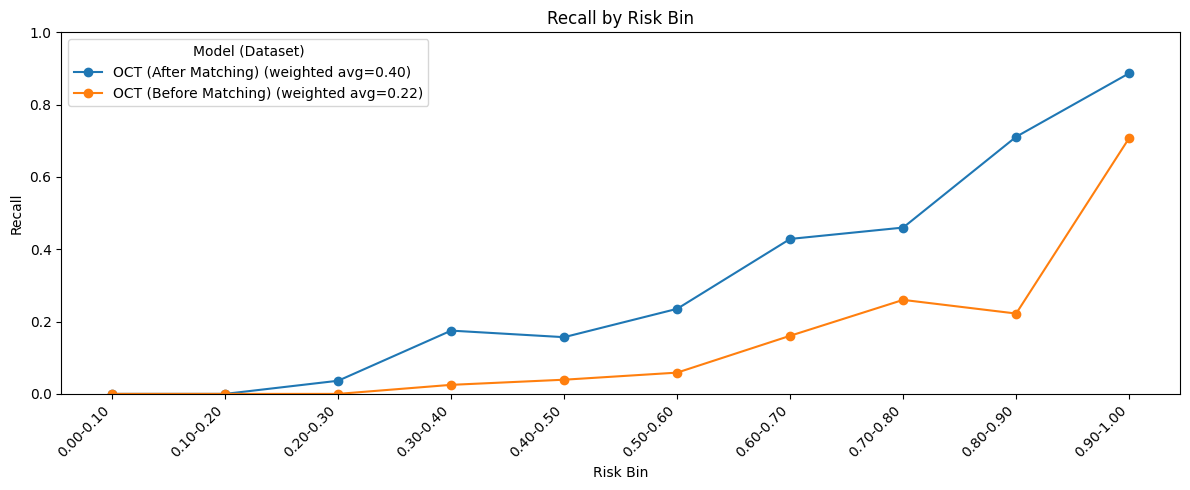

In [74]:
# Concatenate all results
oct_results = pd.concat([oct_results_before, oct_results_after], ignore_index=True)

# Compare models
evaluate_model_by_risk_bin.plot_model_comparison_by_risk_bin(oct_results,metric = "recall")


In [15]:

# Logistic Regression for binary high-cost prediction
print("Training Logistic Regression model...")
log_pipeline = model_pipeline.get_logistic_pipeline(
    df=X_train,categorical_cols=CAT_COLUMNS, numeric_cols=TRUE_NUM_COLUMNS, C=0.1, max_iter=1000,
)
log_pipeline.fit(X_train, y_train)  # Binary classification

# Random Forest for binary high-cost prediction
print("Training Random Forest model...")
rf_pipeline = model_pipeline.get_random_forest_pipeline(
    df=X_train ,categorical_cols=CAT_COLUMNS, numeric_cols=TRUE_NUM_COLUMNS, 
)
rf_pipeline.fit(X_train, y_train )  # Binary classification

# Gradient Boosting for binary high-cost prediction
print("Training Gradient Boosting model...")
gb_pipeline = model_pipeline.get_histgb_pipeline(
   df=X_train ,categorical_cols=CAT_COLUMNS, numeric_cols=TRUE_NUM_COLUMNS, balance_classes = True
)
gb_pipeline.fit(X_train, y_train)  # Binary classification

# ===== Evaluate models using standard metrics =====
print("\nStandard evaluation metrics:")

print("\nLogistic Regression:")
model_pipeline.evaluate_model_auc(log_pipeline, X_test, y_test, highcost_cutoff=highcost_cutoff, optimal_threshold=True)

print("\nRandom Forest:")
model_pipeline.evaluate_model_auc(rf_pipeline, X_test, y_test, highcost_cutoff=highcost_cutoff, optimal_threshold=True)

print("\nGradient Boosting:")
model_pipeline.evaluate_model_auc(gb_pipeline, X_test, y_test, highcost_cutoff=highcost_cutoff, optimal_threshold=False)



Training Logistic Regression model...
→ Building preprocessor:
   • OneHotEncoder on: ['AGEGRP', 'SEX', 'REGION', 'INDSTRY']
   • StandardScaler on: ['cost_stratum_2017', '2017Q1_ckd_cost', '2017Q1_ckd_claims', '2017Q1_direct_ckd_cost', '2017Q1_procedure_ckd_cost', '2017Q1_comorbidity_ckd_cost', '2017Q2_ckd_cost', '2017Q2_ckd_claims', '2017Q2_direct_ckd_cost', '2017Q2_procedure_ckd_cost', '2017Q2_comorbidity_ckd_cost', '2017Q3_ckd_cost', '2017Q3_ckd_claims', '2017Q3_direct_ckd_cost', '2017Q3_procedure_ckd_cost', '2017Q3_comorbidity_ckd_cost', '2017Q4_ckd_cost', '2017Q4_ckd_claims', '2017Q4_direct_ckd_cost', '2017Q4_procedure_ckd_cost', '2017Q4_comorbidity_ckd_cost', 'total_ckd_cost_2017', 'ckd_cost_trend_2017', 'ckd_cost_volatility_2017', 'util_2017']
Training Random Forest model...
→ Building preprocessor:
   • OneHotEncoder on: ['AGEGRP', 'SEX', 'REGION', 'INDSTRY']
   • StandardScaler on: ['cost_stratum_2017', '2017Q1_ckd_cost', '2017Q1_ckd_claims', '2017Q1_direct_ckd_cost', '2017Q1

In [ ]:
plot_probability_and_calibration(gb_pipeline, X_test, y_test, test_df['risk_bin'])

In [ ]:
# Example: Pass status to the evaluation function
log_results_before = evaluate_metrics_by_risk_bin(
    log_pipeline, X_test, y_test, test_df['risk_bin'],
    highcost_cutoff=highcost_cutoff,
    model_name='Logistic Regression',
    dataset_name='Before Matching'
)# Random Forest results BEFORE matching
rf_results_before = evaluate_metrics_by_risk_bin(
    rf_pipeline, X_test, y_test, test_df['risk_bin'],
    highcost_cutoff=highcost_cutoff,
    model_name='Random Forest',
    dataset_name='Before Matching'
)
# Gradient Boosting results BEFORE matching
gb_results_before = evaluate_metrics_by_risk_bin(
    gb_pipeline, X_test, y_test, test_df['risk_bin'],
    highcost_cutoff=highcost_cutoff,
    model_name='Balanced XGBoost',
    dataset_name='Before Matching'
)



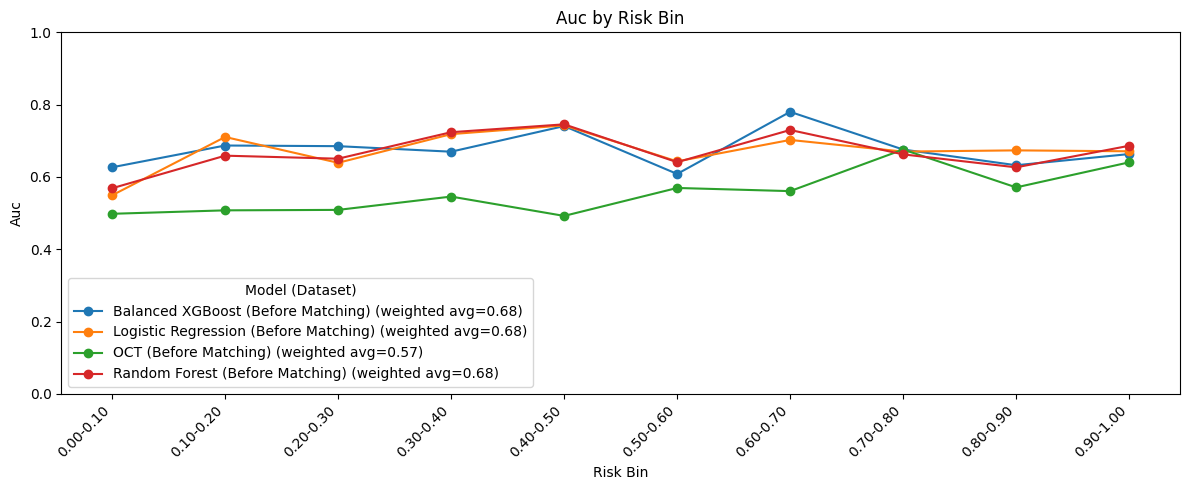

In [76]:
# Concatenate all results
all_results = pd.concat([log_results_before, rf_results_before, gb_results_before,oct_results_before], ignore_index=True)

# Compare models
evaluate_model_by_risk_bin.plot_model_comparison_by_risk_bin(all_results,metric = "auc")


### Matched Model Comparisons


In [93]:
X_train, y_train = matched_train_df[feature_cols], matched_with_target['high_cost_2018']
X_test,y_test = test_df[feature_cols], test_pd['high_cost_2018']
# 5. Create and train models using your existing pipelines
# Logistic Regression model
log_pipeline_matched = model_pipeline.get_logistic_pipeline(
    df=matched_train_df[feature_cols]
,categorical_cols=CAT_COLUMNS, numeric_cols=TRUE_NUM_COLUMNS
)
log_pipeline_matched.fit(X_train, y_train)

# Random Forest model
rf_pipeline_matched = model_pipeline.get_random_forest_pipeline(
    df=matched_train_df[feature_cols]
,categorical_cols=CAT_COLUMNS, numeric_cols=TRUE_NUM_COLUMNS
)
rf_pipeline_matched.fit(X_train, y_train)

# Gradient Boosting model
gb_pipeline_matched = model_pipeline.get_histgb_pipeline(
    df=matched_train_df[feature_cols]
,categorical_cols=CAT_COLUMNS, numeric_cols=TRUE_NUM_COLUMNS
)
gb_pipeline_matched.fit(X_train,y_train)

# 6. Evaluate models (using your existing function)
print("\nLogistic Regression Results:")
model_pipeline.evaluate_model_auc(log_pipeline_matched, X_test, y_test,highcost_cutoff=highcost_cutoff)

print("\nRandom Forest Results:")
model_pipeline.evaluate_model_auc(rf_pipeline_matched, X_test, y_test,highcost_cutoff=highcost_cutoff)

print("\nGradient Boosting Results:")
model_pipeline.evaluate_model_auc(gb_pipeline_matched, X_test, y_test,highcost_cutoff=highcost_cutoff)


→ Building preprocessor:
   • OneHotEncoder on: ['AGEGRP', 'SEX', 'REGION', 'INDSTRY']
   • StandardScaler on: ['cost_stratum_2017', '2017Q1_ckd_cost', '2017Q1_ckd_claims', '2017Q1_direct_ckd_cost', '2017Q1_procedure_ckd_cost', '2017Q1_comorbidity_ckd_cost', '2017Q2_ckd_cost', '2017Q2_ckd_claims', '2017Q2_direct_ckd_cost', '2017Q2_procedure_ckd_cost', '2017Q2_comorbidity_ckd_cost', '2017Q3_ckd_cost', '2017Q3_ckd_claims', '2017Q3_direct_ckd_cost', '2017Q3_procedure_ckd_cost', '2017Q3_comorbidity_ckd_cost', '2017Q4_ckd_cost', '2017Q4_ckd_claims', '2017Q4_direct_ckd_cost', '2017Q4_procedure_ckd_cost', '2017Q4_comorbidity_ckd_cost', 'total_ckd_cost_2017', 'ckd_cost_trend_2017', 'ckd_cost_volatility_2017', 'util_2017']
→ Building preprocessor:
   • OneHotEncoder on: ['AGEGRP', 'SEX', 'REGION', 'INDSTRY']
   • StandardScaler on: ['cost_stratum_2017', '2017Q1_ckd_cost', '2017Q1_ckd_claims', '2017Q1_direct_ckd_cost', '2017Q1_procedure_ckd_cost', '2017Q1_comorbidity_ckd_cost', '2017Q2_ckd_cost'

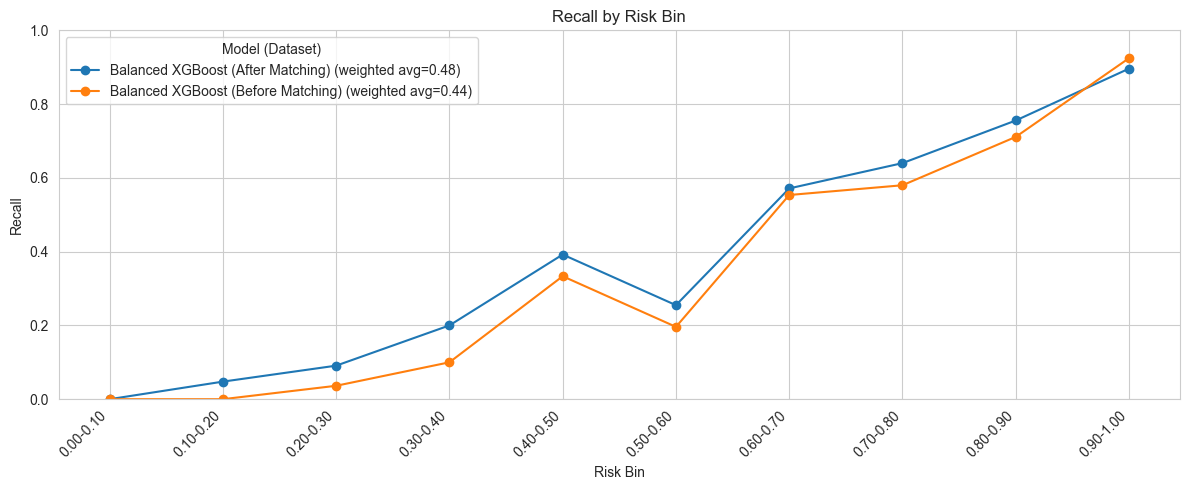

In [97]:


log_results_after = evaluate_metrics_by_risk_bin(
    log_pipeline_matched, X_test, y_test, test_df['risk_bin'],
    highcost_cutoff=highcost_cutoff,
    model_name='Logistic Regression',
    dataset_name='After Matching'
)


# Random Forest results AFTER matching
rf_results_after = evaluate_metrics_by_risk_bin(
    rf_pipeline_matched, X_test, y_test, test_df['risk_bin'],
    highcost_cutoff=highcost_cutoff,
    model_name='Random Forest',
    dataset_name='After Matching'
)


# Gradient Boosting results AFTER matching
gb_results_after = evaluate_metrics_by_risk_bin(
    gb_pipeline_matched, X_test, y_test, test_df['risk_bin'],
    highcost_cutoff=highcost_cutoff,
    model_name='Balanced XGBoost',
    dataset_name='After Matching'
)


# Concatenate all results
all_results = pd.concat([
    #log_results_before,log_results_after, 
    gb_results_before,gb_results_after,
    #rf_results_before, rf_results_after, 
], ignore_index=True)

# Compare models
evaluate_model_by_risk_bin.plot_model_comparison_by_risk_bin(all_results, metric= 'recall')



### Feature Importance


Analyzing Logistic Regression feature importance...


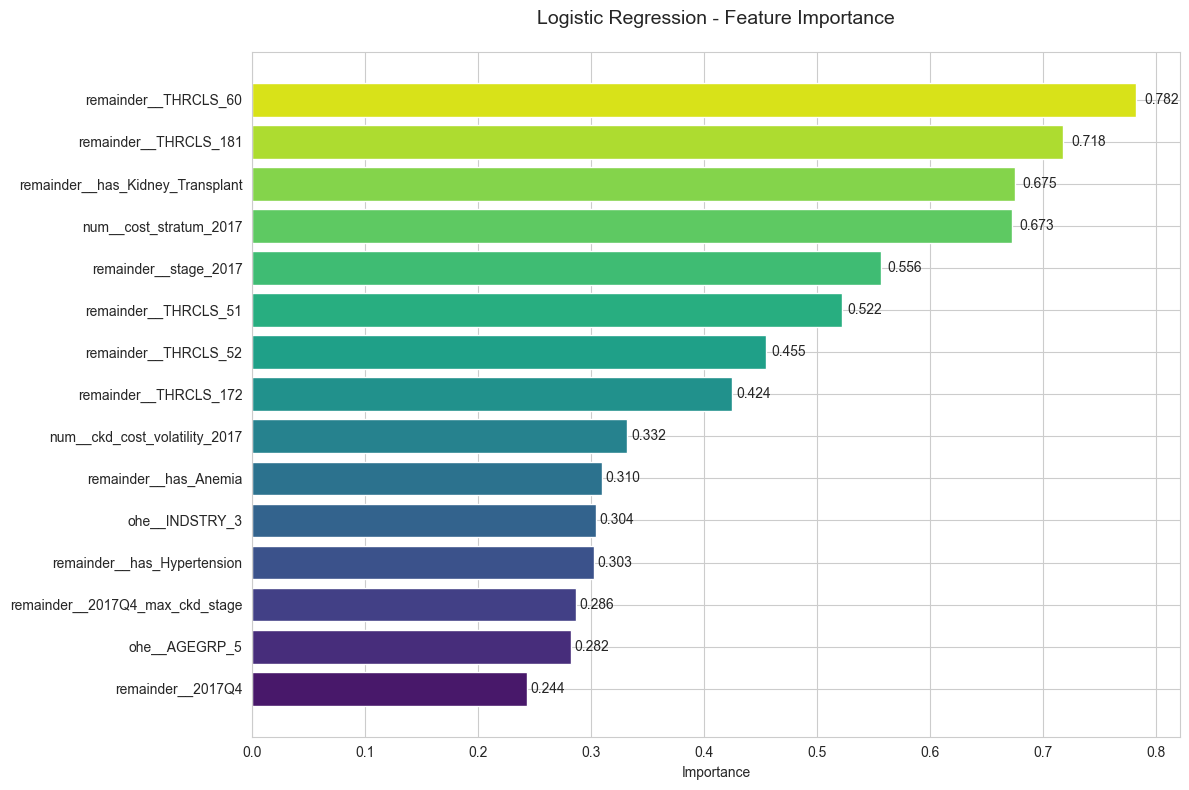

Top 10 features from Logistic Regression:
                feature  importance
0  remainder__THRCLS_60    0.782078

Analyzing Random Forest feature importance...


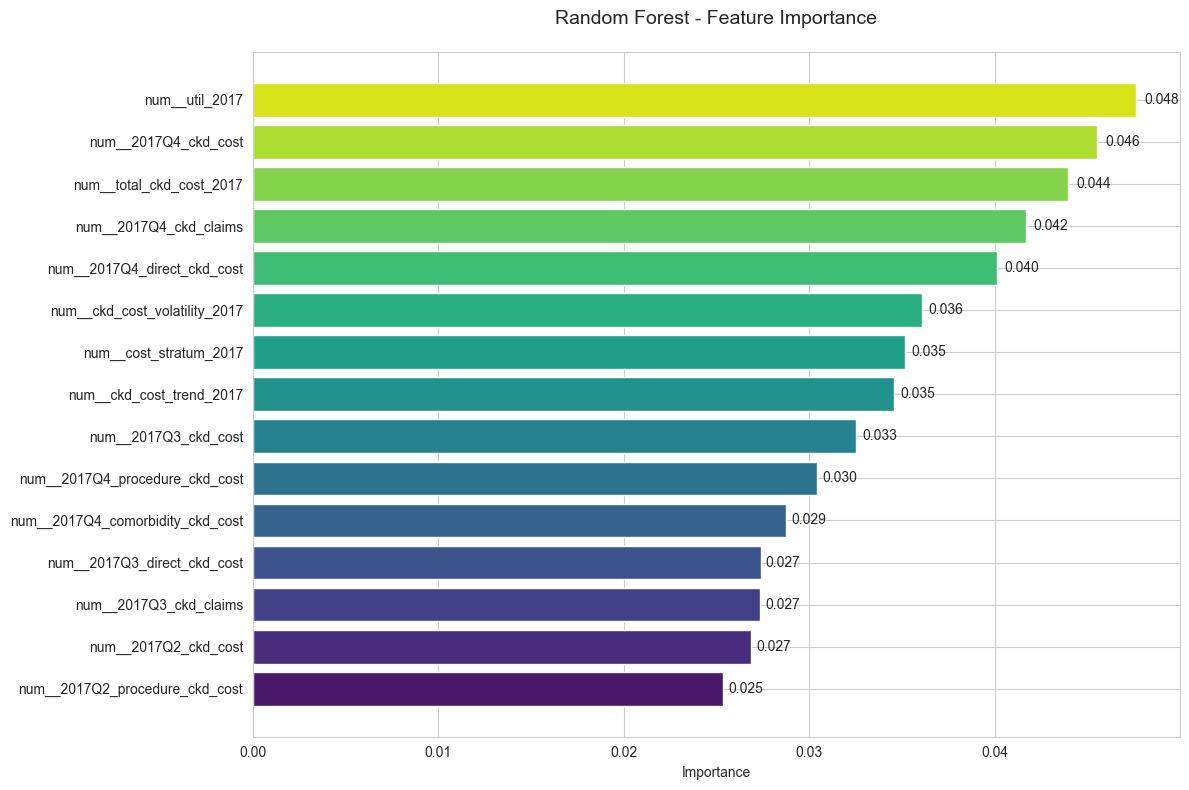

Top 10 features from Random Forest:
          feature  importance
0  num__util_2017    0.047612


In [78]:
import feature_importance
importlib.reload(feature_importance)
importlib.reload(model_pipeline)

# Logistic Regression feature importance
print("\nAnalyzing Logistic Regression feature importance...")
log_fig, log_importance = feature_importance.analyze_feature_importance(
    log_pipeline, X_train, y_train, X_test, y_test,
    method='built_in', top_n=15, 
    title="Logistic Regression - Feature Importance",
    return_df=True
)
plt.show()
print("Top 10 features from Logistic Regression:")
print(log_importance.head(1))

# Random Forest feature importance
print("\nAnalyzing Random Forest feature importance...")
rf_fig, rf_importance = feature_importance.analyze_feature_importance(
    rf_pipeline, X_train, y_train, X_test, y_test,
    method='built_in', top_n=15, 
    title="Random Forest - Feature Importance",
    return_df=True
)
plt.show()
print("Top 10 features from Random Forest:")
print(rf_importance.head(1))


In [ ]:
# Gradient Boosting feature importance
print("\nAnalyzing Gradient Boosting feature importance...")
gb_fig, gb_importance = feature_importance.analyze_feature_importance(
    gb_pipeline, X_train, y_train, X_test, y_test,
    method='permutation', top_n=15, 
    title="Gradient Boosting - Feature Importance",
)
plt.show()
print("Top 10 features from Gradient Boosting:")
print(gb_importance.head(10))
